<a href="https://colab.research.google.com/github/saja-zenaty/test/blob/main/file1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

In [3]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
train_data = torchvision.datasets.CIFAR10(root='./data',train=True, download=True, transform=transform)
test_data =  torchvision.datasets.CIFAR10(root='./data',train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data , batch_size=32 , shuffle=True ,num_workers=2)
test_loader = torch.utils.data.DataLoader(test_data , batch_size=32 , shuffle=True ,num_workers=2)

In [10]:
image , label = train_data[0]

In [13]:
print('Images shape : ', image.shape)

Images shape :  torch.Size([3, 32, 32])


In [14]:
class_names = ['plane' ,'car','bird','cat','deer','dog','frog','horse','ship','truck']

In [20]:
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(3,12,5) #(12,28,28)
    self.pool = nn.MaxPool2d(2,2) #(12,14,14)
    self.conv2 = nn.Conv2d(12,24,5) #(24,10,10) -->(24,5,5)
    self.fc1 = nn.Linear(24*5*5,120)
    self.fc2 = nn.Linear(120,84)
    self.fc3 = nn.Linear(84,10)

  def forward(self,x):
    x = self.pool(F.relu(self.conv1(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x,1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x


In [21]:
net =  NeuralNet()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(),lr=0.001,momentum=0.9)

In [22]:
for epoch in range(30):
  print(f"Training epoch {epoch}...")

  running_loss = 0.0
  for i , data in enumerate(train_loader):
    inputs , labels = data
    optimizer.zero_grad()

    outputs = net(inputs)
    loss = loss_function(outputs,labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  print(f'Loss:{running_loss/len(train_loader):.4f}')


Training epoch 0...
Loss:2.1781
Training epoch 1...
Loss:1.7349
Training epoch 2...
Loss:1.5115
Training epoch 3...
Loss:1.3973
Training epoch 4...
Loss:1.3059
Training epoch 5...
Loss:1.2333
Training epoch 6...
Loss:1.1716
Training epoch 7...
Loss:1.1131
Training epoch 8...
Loss:1.0631
Training epoch 9...
Loss:1.0201
Training epoch 10...
Loss:0.9755
Training epoch 11...
Loss:0.9333
Training epoch 12...
Loss:0.8929
Training epoch 13...
Loss:0.8545
Training epoch 14...
Loss:0.8192
Training epoch 15...
Loss:0.7856
Training epoch 16...
Loss:0.7555
Training epoch 17...
Loss:0.7303
Training epoch 18...
Loss:0.7004
Training epoch 19...
Loss:0.6765
Training epoch 20...
Loss:0.6524
Training epoch 21...
Loss:0.6287
Training epoch 22...
Loss:0.6053
Training epoch 23...
Loss:0.5847
Training epoch 24...
Loss:0.5601
Training epoch 25...
Loss:0.5421
Training epoch 26...
Loss:0.5173
Training epoch 27...
Loss:0.5014
Training epoch 28...
Loss:0.4843
Training epoch 29...
Loss:0.4603


In [23]:
torch.save(net.state_dict(),'./cifar_net.pth')

In [24]:
net = NeuralNet()
net.load_state_dict(torch.load('./cifar_net.pth'))

<All keys matched successfully>

In [25]:
correct = 0
total = 0
net.eval()

with torch.no_grad():
  for data in test_loader:
    images , labels = data
    outputs = net(images)
    _,predicted = torch.max(outputs.data,1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 66 %


In [34]:
new_transform = transforms.Compose([
   transforms.Resize((32,32)),
   transforms.ToTensor(),
   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def load_image(image_path):
  image = Image.open(image_path)
  image = new_transform(image)
  image = torch.unsqueeze(image,0)
  return image

image_paths = ['/content/data/example1.jpeg','/content/data/example2.jpeg','/content/data/example4.jpeg']
images = [load_image(image_path) for image_path in image_paths]

net.eval()
with torch.no_grad():
  for image in images:
    output = net(image)
    _,predicted = torch.max(output.data,1)
    print(class_names[predicted])

dog
deer
plane


In [38]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


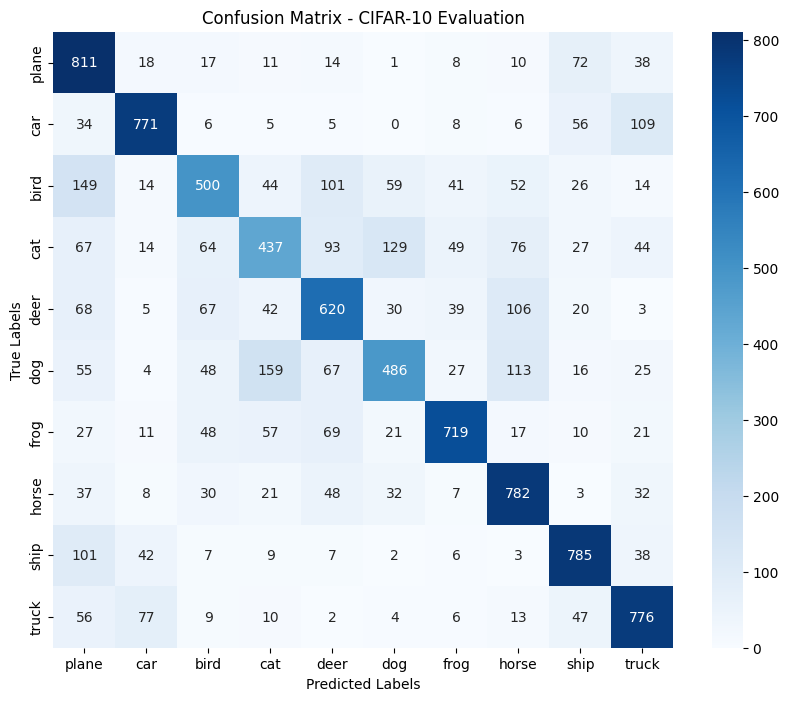

In [39]:
import sklearn
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
all_preds = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)

        outputs = net(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix - CIFAR-10 Evaluation')
plt.show()